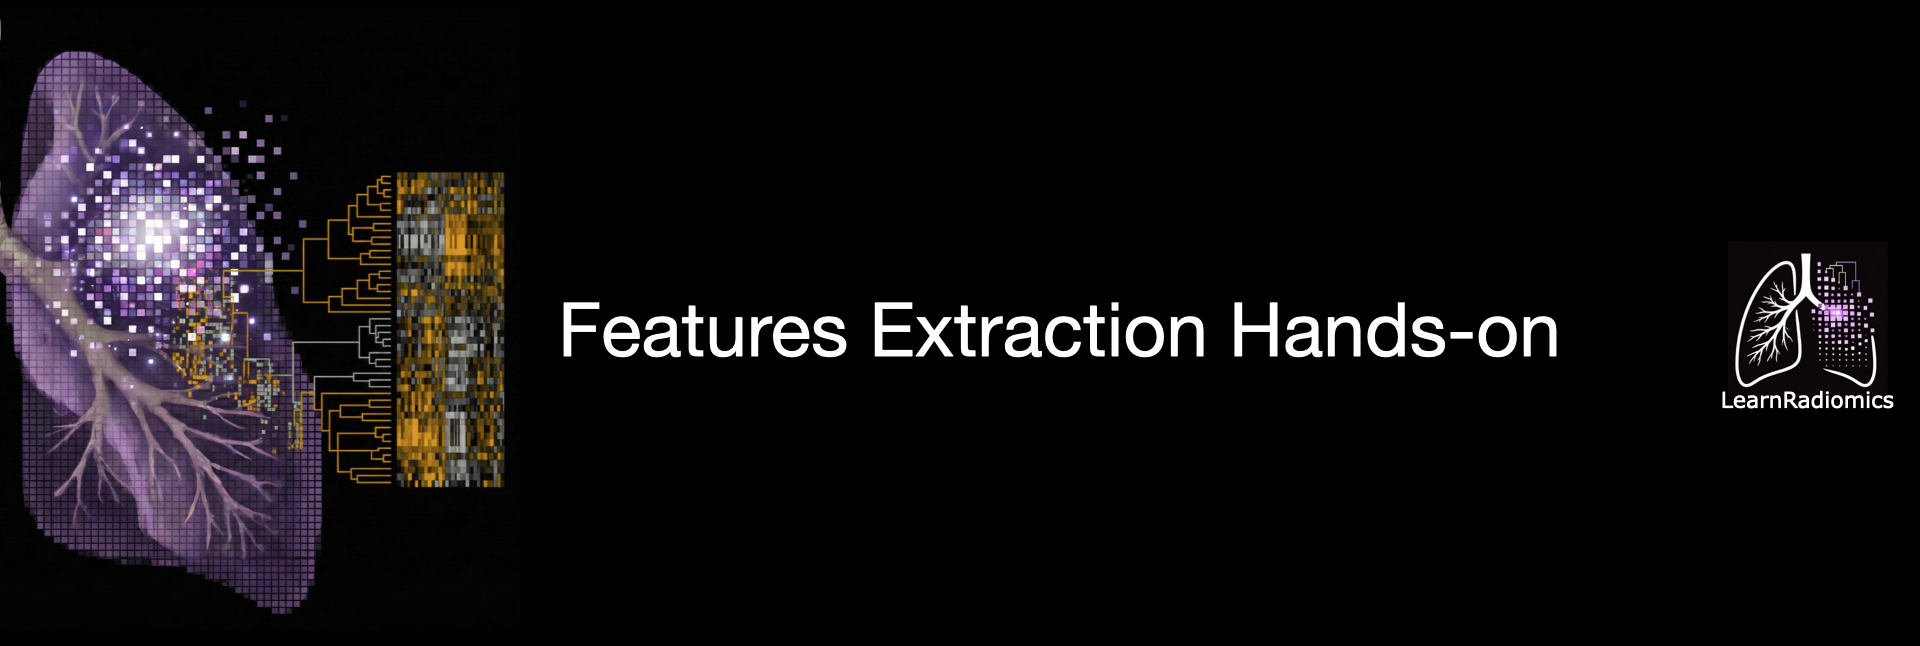

In [ ]:
## install libraries
!pip install SimpleITK
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git


In [ ]:
## Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math
import requests
import json
import SimpleITK as sitk
import radiomics
from radiomics import featureextractor
from collections import Counter

## visualization setup
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


## Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Download Kaggle token to access the dataset
json_response = requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")
token = json.loads(json_response.text)

with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load data from Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/learnradiomics-feature-extraction-data
! unzip /content/learnradiomics-feature-extraction-data


In [ ]:
### Function to select slices with a segmentation mask
def select_slice(mask_array):
  z_has_label = mask_array.any(axis=(1, 2))
  z_idx = np.where(z_has_label)[0]
  middle_slice = math.ceil(z_idx.shape[0]/2)
  return(z_idx[middle_slice])

In [ ]:
data = pd.read_csv('/content/NSCLC_Radiogenomics_sampledata.csv')
print(data.shape)

In [ ]:
data.head(5)

In [ ]:
Counter(data['EGFR mutation status'])

In [ ]:
### Load directories
PATH_IMG = '/content/data_radiomics/images'
PATH_MASKS = '/content/data_radiomics/masks'

In [ ]:
## Verify that all images and masks are present

all_files_ok = True
for patient in data['Case ID']:
  image_file = os.path.join(PATH_IMG, f'{patient}_chest_ct_image.nrrd')
  mask_file = os.path.join(PATH_MASKS, f'{patient}_chest_ct_segmentation.nrrd')
  if not os.path.exists(image_file):
    print(f"Problem with IMG: {patient}")
    all_files_ok = False
  else:
    continue
  if not os.path.exists(mask_file):
    print(f"Problem with MASK: {patient}")
    all_files_ok = False
  else:
    continue

if all_files_ok:
  print("All images and masks are OK")


### Data visualization

In [ ]:
### Load a random case
random_index = np.random.randint(0, len(data['Case ID']))
patient = data['Case ID'].iloc[random_index]

image_file = os.path.join(PATH_IMG, f'{patient}_chest_ct_image.nrrd')
mask_file = os.path.join(PATH_MASKS, f'{patient}_chest_ct_segmentation.nrrd')

image_itk = sitk.ReadImage(image_file)
image_array = sitk.GetArrayFromImage(image_itk)

mask_itk = sitk.ReadImage(mask_file)
mask_array = sitk.GetArrayFromImage(mask_itk)

print(image_array.shape)
print(mask_array.shape)

In [ ]:
slice_index = select_slice(mask_array)

plt.figure()
plt.imshow(image_array[slice_index, :, :], cmap='gray')
plt.imshow(mask_array[slice_index, :, :], cmap='inferno', alpha=0.1)
plt.contour(mask_array[slice_index, :, :], levels=[0.5], colors='cyan', linewidths=2)
plt.title(f"Patient: {patient}")
plt.show()

## Feature extraction

In [ ]:
# Parameter configuration
params = {
    'imageType': {
        'Original': {}
    },
    'setting': {
        'normalize': True,
        'binWidth': 75,
        'resampledPixelSpacing': [1, 1, 1],
        'interpolator': 'sitkBSpline',
        'label': 1
    },
    'featureClass': {
        'shape': [],
        'firstorder': [],
        'glcm': [],
        'glrlm': [],
        'glszm': [],
        'gldm': [],
        'ngtdm': []
    }
}

In [ ]:
### Create feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor(params)

### Provide an image with its mask
result = extractor.execute(image_itk, mask_itk)

In [ ]:
### Extracted variables
print("Number of extracted variables:", len(result.keys()))
print("Features:")
result.keys()

### Extraction for multiple patients

In [ ]:

extractor = featureextractor.RadiomicsFeatureExtractor(params)

results_list = []

for patient in data['Case ID'].iloc[0:2]:
  print("Processing...", patient)
  image_file = os.path.join(PATH_IMG, f'{patient}_chest_ct_image.nrrd')
  mask_file = os.path.join(PATH_MASKS, f'{patient}_chest_ct_segmentation.nrrd')
  try:
    image_itk = sitk.ReadImage(image_file)
    mask_itk = sitk.ReadImage(image_file)

    result = extractor.execute(image_itk, mask_itk)
    ## Save as a dictionary and add identifier
    row_dict = {'Case ID': patient}
    row_dict.update(result)

    results_list.append(row_dict)

  except Exception as e:
    print(f'Error in patient {patient}: {e}')

df_features = pd.DataFrame(results_list)
df_features.shape


In [ ]:
df_features.head(10)

### Extraction with filters

In [ ]:
# Parameter configuration
params_with_filters = {
    'imageType': {
        'Original': {},
        'LoG': {'sigma': [1.0, 2.0, 3.0]},
        'Wavelet': {}
    },
    'setting': {
        'normalize': True,
        'binWidth': 50,
        'resampledPixelSpacing': [1.0, 1.0, 1.0],
        'interpolator': 'sitkBSpline',
        'preCrop': True,
        'padDistance': 5,
        'label': 1
    },
    'featureClass': {
        'shape': [],
        'firstorder': [],
        'glcm': [],
        'glrlm': [],
        'glszm': [],
        'gldm': [],
        'ngtdm': []
    }
}

In [ ]:
extractor = featureextractor.RadiomicsFeatureExtractor(params_with_filters)

results_list_filters = []

for patient in data['Case ID'].iloc[0:3]:
  image_file = os.path.join(PATH_IMG, f'{patient}_chest_ct_image.nrrd')
  mask_file = os.path.join(PATH_MASKS, f'{patient}_chest_ct_segmentation.nrrd')
  try:
    image_itk = sitk.ReadImage(image_file)
    mask_itk = sitk.ReadImage(image_file)

    result = extractor.execute(image_itk, mask_itk)
    ## Save as a dictionary and add identifier
    row_dict = {'Case ID': patient}
    row_dict.update(result)

    results_list_filters.append(row_dict)

  except Exception as e:
    print(f'Error in patient {patient}: {e}')

df_features_filters = pd.DataFrame(results_list_filters)
df_features_filters.shape


In [ ]:
### Save file
df_features_filters.to_excel('/content/df_features_filters.xlsx', index=False)